In [33]:
# ----------------- Imports -----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.stem import PorterStemmer
from collections import Counter
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
from imblearn.over_sampling import SMOTE

In [35]:
# ----------------- NLTK Setup -----------------
nltk.download('stopwords', download_dir='../static/model')
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()
print("Sample stopwords:", sw[:50])
ps = PorterStemmer()

Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn']


[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
# ----------------- Data Loading and Cleaning -----------------
data = pd.read_csv('../artifacts/tripadvisor_extended_1000.csv')
print("Train data shape:", data.shape)
print("\nTrain data sample:")
print(data.tail(10))
print("\nDuplicates: ", data.duplicated().sum())
print("\nNull values:\n", data.isnull().sum())


Train data shape: (7552, 3)

Train data sample:
        id                                              tweet  label
7542  7543  Enjoyed my time here. The pool was clean, and ...      2
7543  7544  Enjoyed my time here. The pool was clean, and ...      2
7544  7545  Bad experience! The location was good, but eve...      0
7545  7546  Best experience ever! The hotel ambiance was p...      2
7546  7547  Bad experience! The location was good, but eve...      0
7547  7548  The noise was unbearable. Couldn’t sleep all n...      0
7548  7549  Totally regret booking this place. Stay away! ...      0
7549  7550  A reasonable place for a short stay, but nothi...      1
7550  7551  It was fine for a business trip. Nothing too f...      1
7551  7552  Not worth the money. The rooms smelled bad, an...      0

Duplicates:  0

Null values:
 id       0
tweet    0
label    0
dtype: int64


In [37]:
# ----------------- Preprocessing Function -----------------
def preprocess_text(text):
    # 1. Convert text to lowercase
    text = " ".join(word.lower() for word in text.split())
    # 2. Remove links
    text = " ".join(re.sub(r'^https?:\/\/.*[\r\n]*', '', word, flags=re.MULTILINE) for word in text.split())
    # 3. Remove punctuations
    for p in string.punctuation:
        text = text.replace(p, '')
    # 4. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 5. Remove stopwords using the loaded list (sw)
    text = " ".join(word for word in text.split() if word not in sw)
    # 6. Apply stemming (Porter Stemmer)
    text = " ".join(ps.stem(word) for word in text.split())
    return text


In [38]:
# Apply preprocessing to the 'tweet' column
data["tweet"] = data["tweet"].apply(preprocess_text)
print("Sample preprocessed tweets:\n", data["tweet"].head())

Sample preprocessed tweets:
 0    nice averag stay recent midoctob got good deal...
1    westin rio mar worth trip friend return day we...
2    okay great stay apolo tryp night pretti standa...
3    good great stay friend neri earli thought grea...
4    poor custom servic poor custom servic respond ...
Name: tweet, dtype: object


In [43]:
# ----------------- Vocabulary Building -----------------
vocab = Counter()
for sentence in data['tweet']:
    vocab.update(sentence.split())
print("Most common tokens:\n", vocab.most_common(50))
print("Dataset Shape: ", data.shape)
print("Vocabulary Size: ", len(vocab))

Most common tokens:
 [('room', 17502), ('hotel', 16450), ('stay', 9467), ('nt', 7363), ('good', 5676), ('great', 5507), ('staff', 5147), ('night', 5086), ('day', 4647), ('time', 4630), ('nice', 4435), ('servic', 4185), ('locat', 4169), ('like', 3668), ('beach', 3667), ('place', 3641), ('resort', 3449), ('clean', 3426), ('food', 3378), ('restaur', 3197), ('bed', 2902), ('walk', 2817), ('pool', 2773), ('breakfast', 2705), ('peopl', 2515), ('realli', 2467), ('got', 2407), ('small', 2362), ('look', 2356), ('book', 2320), ('want', 2281), ('area', 2272), ('help', 2245), ('desk', 2172), ('littl', 2064), ('need', 2035), ('check', 2034), ('price', 2011), ('bathroom', 2001), ('make', 1978), ('ask', 1921), ('water', 1912), ('use', 1878), ('bar', 1863), ('friendli', 1840), ('thing', 1789), ('arriv', 1780), ('review', 1779), ('tri', 1775), ('view', 1765)]
Dataset Shape:  (7552, 3)
Vocabulary Size:  30056


In [44]:
# Filter tokens with frequency > 2
tokens = [key for key in vocab if vocab[key] > 1]
print('\nFiltered Token Size: ', len(tokens))


Filtered Token Size:  8518


In [45]:
# Save the filtered vocabulary to a file
def save_vocabulary(lines, filename):
    vocab_data = '\n'.join(lines)
    with open(filename, 'w', encoding="utf-8") as file:
        file.write(vocab_data)
save_vocabulary(tokens, '../static/model/vocabulary2.txt')

In [46]:
# ----------------- Data Splitting -----------------
x = data['tweet']
y = data['label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (6041,)
x_test shape: (1511,)


In [47]:
# ----------------- TF-IDF Vectorization -----------------
# Use TfidfVectorizer with your custom vocabulary (tokens)
tfidf_vectorizer = TfidfVectorizer(vocabulary=tokens, norm='l2')
vectorized_x_train_sparse = tfidf_vectorizer.fit_transform(x_train)
vectorized_x_test_sparse = tfidf_vectorizer.transform(x_test)

In [48]:
# SMOTE does not support sparse matrices; convert to dense
vectorized_x_train = vectorized_x_train_sparse.toarray()
print("Finish TF-IDF vectorization for x_train")
vectorized_x_test = vectorized_x_test_sparse.toarray()
print("Finish TF-IDF vectorization for x_test")

Finish TF-IDF vectorization for x_train
Finish TF-IDF vectorization for x_test


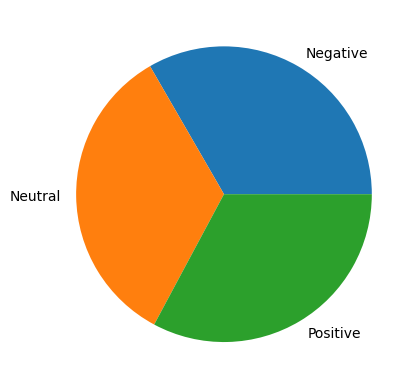

In [49]:
# ----------------- Visualize Class Distribution -----------------
plt.pie(np.array([y_train.value_counts()[0], 
                  y_train.value_counts()[1], 
                  y_train.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()


(6132, 8518) (6132,)
Value counts after SMOTE:
 label
2    2044
0    2044
1    2044
Name: count, dtype: int64


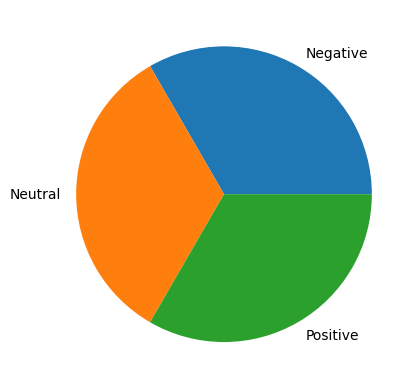

In [50]:
# ----------------- Handling Imbalanced Dataset -----------------
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)
print("Value counts after SMOTE:\n", y_train_smote.value_counts())
plt.pie(np.array([y_train_smote.value_counts()[0], 
                  y_train_smote.value_counts()[1], 
                  y_train_smote.value_counts()[2]]),
        labels=['Negative', 'Neutral', 'Positive'])
plt.show()

In [51]:
# ----------------- Model Training and Evaluation Functions -----------------
def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Training Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')
    
def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pr = round(precision_score(y_act, y_pred, average='weighted'), 3)
    rec = round(recall_score(y_act, y_pred, average='weighted'), 3)
    f1 = round(f1_score(y_act, y_pred, average='weighted'), 3)
    print(f'Testing Scores: \n\tAccuracy = {acc}\n\tPrecision = {pr}\n\tRecall = {rec}\n\tF1-Score = {f1}')

In [52]:
# ----------------- Original Model Training -----------------
# (For comparison, you still train your original models with TF-IDF features)

In [53]:
# Logistic Regression (Original)
lr = LogisticRegression(max_iter=500)
lr.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = lr.predict(vectorized_x_train_smote)
y_test_pred = lr.predict(vectorized_x_test)
print("Logistic Regression (Original):")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)

Logistic Regression (Original):
Training Scores: 
	Accuracy = 0.906
	Precision = 0.906
	Recall = 0.906
	F1-Score = 0.906
Testing Scores: 
	Accuracy = 0.797
	Precision = 0.798
	Recall = 0.797
	F1-Score = 0.797


In [54]:
# MultinomialNB (Original)
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = mnb.predict(vectorized_x_train_smote)
y_test_pred = mnb.predict(vectorized_x_test)
print("\nMultinomialNB (Original):")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)



MultinomialNB (Original):
Training Scores: 
	Accuracy = 0.86
	Precision = 0.861
	Recall = 0.86
	F1-Score = 0.86
Testing Scores: 
	Accuracy = 0.776
	Precision = 0.78
	Recall = 0.776
	F1-Score = 0.778


In [55]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = dt.predict(vectorized_x_train_smote)
y_test_pred = dt.predict(vectorized_x_test)
print("\nDecision Tree:")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)


Decision Tree:
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores: 
	Accuracy = 0.59
	Precision = 0.591
	Recall = 0.59
	F1-Score = 0.59


In [56]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred = rf.predict(vectorized_x_train_smote)
y_test_pred = rf.predict(vectorized_x_test)
print("\nRandom Forest:")
training_scores(y_train_smote, y_train_pred)
validation_scores(y_test, y_test_pred)


Random Forest:
Training Scores: 
	Accuracy = 1.0
	Precision = 1.0
	Recall = 1.0
	F1-Score = 1.0
Testing Scores: 
	Accuracy = 0.749
	Precision = 0.747
	Recall = 0.749
	F1-Score = 0.748


In [57]:
# # SVC
# svc = SVC()
# svc.fit(vectorized_x_train_smote, y_train_smote)
# y_train_pred = svc.predict(vectorized_x_train_smote)
# y_test_pred = svc.predict(vectorized_x_test)
# print("\nSVC:")
# training_scores(y_train_smote, y_train_pred)
# validation_scores(y_test, y_test_pred)

In [58]:
# ----------------- Hyperparameter Tuning -----------------
# Hyperparameter tuning for MultinomialNB and Logistic Regression using GridSearchCV.
# MultinomialNB tuning:
nb_param_grid = {'alpha': [0.5, 1.0, 2.0, 5.0, 10.0]}
grid_mnb = GridSearchCV(MultinomialNB(), nb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_mnb.fit(vectorized_x_train_smote, y_train_smote)
print("\nBest parameters for MultinomialNB:", grid_mnb.best_params_)
print("Best cross-validation score (MultinomialNB):", grid_mnb.best_score_)
best_mnb = grid_mnb.best_estimator_
y_train_pred_nb = best_mnb.predict(vectorized_x_train_smote)
y_test_pred_nb = best_mnb.predict(vectorized_x_test)
print("\nMultinomialNB (Tuned):")
training_scores(y_train_smote, y_train_pred_nb)
validation_scores(y_test, y_test_pred_nb)


Best parameters for MultinomialNB: {'alpha': 0.5}
Best cross-validation score (MultinomialNB): 0.7829399947616901

MultinomialNB (Tuned):
Training Scores: 
	Accuracy = 0.876
	Precision = 0.876
	Recall = 0.876
	F1-Score = 0.876
Testing Scores: 
	Accuracy = 0.778
	Precision = 0.78
	Recall = 0.778
	F1-Score = 0.779


In [59]:
# Logistic Regression tuning:
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100, 1000]}
lr_tuned = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
grid_lr = GridSearchCV(lr_tuned, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(vectorized_x_train_smote, y_train_smote)
print("\nBest Logistic Regression Parameters:", grid_lr.best_params_)
print("Best cross-validation score (Logistic Regression):", grid_lr.best_score_)
best_lr = grid_lr.best_estimator_
y_train_pred_lr = best_lr.predict(vectorized_x_train_smote)
y_test_pred_lr = best_lr.predict(vectorized_x_test)
print("\nLogistic Regression (Tuned):")
training_scores(y_train_smote, y_train_pred_lr)
validation_scores(y_test, y_test_pred_lr)

D:\1.ICBT\FINAL_RESEARCH_PROJECT\Back_End\travel_app_ml_back_end\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Logistic Regression Parameters: {'C': 1}
Best cross-validation score (Logistic Regression): 0.7923974042446262

Logistic Regression (Tuned):
Training Scores: 
	Accuracy = 0.906
	Precision = 0.906
	Recall = 0.906
	F1-Score = 0.906
Testing Scores: 
	Accuracy = 0.797
	Precision = 0.798
	Recall = 0.797
	F1-Score = 0.797


In [60]:

# ----------------- Ensemble via Voting Classifier -----------------
from sklearn.ensemble import VotingClassifier
# Create an ensemble that uses soft voting (using predicted probabilities)
ensemble = VotingClassifier(estimators=[('lr', best_lr), ('nb', best_mnb)],
                            voting='soft', n_jobs=-1)
ensemble.fit(vectorized_x_train_smote, y_train_smote)
y_train_pred_ensemble = ensemble.predict(vectorized_x_train_smote)
y_test_pred_ensemble = ensemble.predict(vectorized_x_test)
print("\nEnsemble Voting Classifier (Tuned Logistic Regression + Tuned MultinomialNB):")
training_scores(y_train_smote, y_train_pred_ensemble)
validation_scores(y_test, y_test_pred_ensemble)



Ensemble Voting Classifier (Tuned Logistic Regression + Tuned MultinomialNB):
Training Scores: 
	Accuracy = 0.899
	Precision = 0.899
	Recall = 0.899
	F1-Score = 0.899
Testing Scores: 
	Accuracy = 0.797
	Precision = 0.799
	Recall = 0.797
	F1-Score = 0.798


In [32]:
# ----------------- Save the Final Model -----------------
# Save the best performing tuned model (choose one, for example the tuned Logistic Regression)
with open('../static/model/model_final_test.pickle','wb') as file:
    pickle.dump(best_lr, file)